In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma

import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [12]:
def _jPETH(session,names):

    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval')
    event = isru.loadHpcPfcEvents(session,regions=R,names=['ripples','down','spindles'])
    isa = R.eventIntervals('slownr')
    on = R.eventIntervals('slowavalnr')
    event['off_on'], event['on_off'] = isru.ISTransitions(isa,on)
    event['nr'] = R.spikes(regs='nr',when=isa)[:,0]

    joint, null, diff, t0, t1, peth0, peth1 = fma.analysis.jointPETH((event[names[0]],event[names[1]]), event[names[2]],bin=0.05,limits=(-1,1),return_peths=True)

    return joint, null, diff, t0, t1, peth0, peth1

In [13]:
# test one session
names = ['ripples','nr','down']
session = fma.data.readBatchFile(batch_file)[0][20]
print(f'session: {session}')
joint, null, diff, t0, t1, peth0, peth1 = _jPETH(session,names)

session: /mnt/hubel-data-140/karadoc/Rat004_20240308/Rat004_20240308.xml


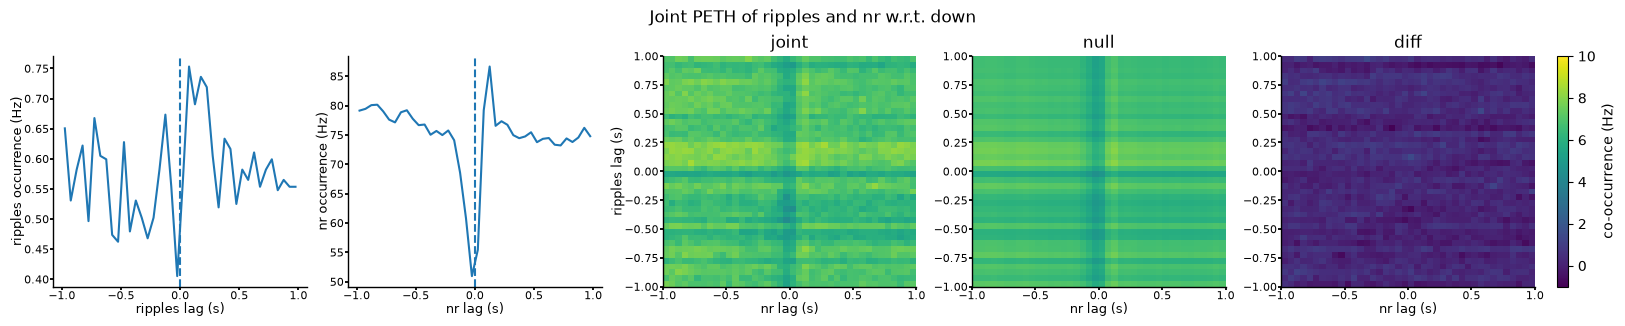

In [14]:
fig, ax = fma.plotting.makeFigure(f'Joint PETH of {names[0]} and {names[1]} w.r.t. {names[2]}',n=(1,5),size=(41,8))

ax[0].axvline(0,ls='--')
ax[0].plot(t0,peth0)
ax[1].axvline(0,ls='--')
ax[1].plot(t1,peth1)
ax[1].set(ylabel=f'{names[1]} occurrence (Hz)')

vmin = -1
vmax = 10
fma.plotting.plotColorMap(joint,x=t1,y=t0,vmin=vmin,vmax=vmax,ax=ax[2])
ax[2].set(ylabel=f'{names[0]} lag (s)',title='joint')
fma.plotting.plotColorMap(null,x=t1,y=t0,vmin=vmin,vmax=vmax,ax=ax[3])
ax[3].set(title='null')
h = fma.plotting.plotColorMap(diff,x=t1,y=t0,vmin=vmin,vmax=vmax,ax=ax[4],bar='co-occurrence (Hz)')
ax[4].set(title='diff'); fma.plotting.setProp(ax,xlabel=f'{names[1]} lag (s)')
ax[0].set(xlabel=f'{names[0]} lag (s)',ylabel=f'{names[0]} occurrence (Hz)');